# Homework 6

## FINM 35700 - Spring 2026

Garrett White

This homework relies on following data files:

Government and corporate bonds
- the bond symbology file `bond_symbology`,
- the "on-the-run" treasuries data file `govt_on_the_run`,
- the bond market data file `bond_market_prices_eod`,

Interest Rate & Credit Default Swaps
- the SOFR OIS symbology file `sofr_swap_symbology`,
- the SOFR swaps market data file `sofr_swaps_market_data_eod`,
- the CDS spreads market data file `cds_market_data_eod`.

In [2]:
!pip install QuantLib-Python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.2/20.2 MB 57.0 MB/s eta 0:00:00


In [3]:
from google.colab import files
import zipfile
import os

uploaded = files.upload()

zip_path = list(uploaded.keys())[0]

extract_path = "/content/unzipped_files"
os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print(f"\nExtracted to: {extract_path}\n")

for root, dirs, files in os.walk(extract_path):
    level = root.replace(extract_path, "").count(os.sep)
    indent = "  " * level
    print(f"{indent}{os.path.basename(root)}/")

    subindent = "  " * (level + 1)
    for f in files:
        print(f"{subindent}{f}")

Saving UChicago_FINM_35700_CreditMarkets_Spring2026_Homework_6.zip to UChicago_FINM_35700_CreditMarkets_Spring2026_Homework_6.zip

Extracted to: /content/unzipped_files

unzipped_files/
  UChicago_FINM_35700_CreditMarkets_Spring2026_Homework_6/
    FINM 35700_CreditMarkets_Spring2026_Examples_QuantLib_Basics.ipynb
    FINM 35700_CreditMarkets_Spring2026_Homework_6.ipynb
    FINM 35700_CreditMarkets_Spring2026_Examples_QuantLib_Advanced.ipynb
    credit_market_tools.py
    data/
      cdx_symbology.xlsx
      sofr_swaps_market_data_eod.xlsx
      govt_on_the_run.xlsx
      bond_market_prices_eod.xlsx
      cds_market_data_eod.xlsx
      bond_symbology.xlsx
      cdx_ig_46_5y_basket_composition.xlsx
      sofr_swaps_symbology.xlsx
      ~$call_schedules.xlsx


In [4]:
import sys

extract_path = "/content/unzipped_files"

for root, dirs, files in os.walk(extract_path):
    if "credit_market_tools.py" in files:
        base_path = root
        break

print("Using path:", base_path)

sys.path.append(base_path)

from credit_market_tools import *

print("credit_market_tools imported successfully")

calc_date = ql.Date(23, 3, 2026)
ql.Settings.instance().evaluationDate = calc_date

as_of_date = pd.to_datetime('2026-03-23')

Using path: /content/unzipped_files/UChicago_FINM_35700_CreditMarkets_Spring2026_Homework_6
credit_market_tools imported successfully


-----------------------------------------------------------
# Problem 1: Pricing bonds in the Merton Structural Credit Model
## Follow Lecture 6, "Structural Credit Default Models"

## a. Company balance sheet metrics & fair value of equity
- Assets of $100 MM
- Liabilities of $75 MM face value, consisting of one zero coupon bond.
- Bond maturity is at T = 5 years
- Asset volatility at 15% (log-normal annualized vol)
- Flat risk-free interest rates of 4%

Compute the company Leverage, "Book Value of Equity" and fair value of equity metrics.


In [6]:
import numpy as np
from scipy.stats import norm

V0    = 100e6
F     = 75e6
T     = 5.0
sigma = 0.15
r     = 0.04

book_equity   = V0 - F
leverage_book = F / V0
leverage_eq   = F / book_equity

d1 = (np.log(V0 / F) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
d2 = d1 - sigma * np.sqrt(T)

PV_F   = F * np.exp(-r * T)
E_fair = V0 * norm.cdf(d1) - PV_F * norm.cdf(d2)
D_fair = V0 - E_fair

credit_spread_bps    = (-np.log(D_fair / F) / T - r) * 1e4
PD_rn                = norm.cdf(-d2)
EV_given_default     = V0 * np.exp(r * T) * norm.cdf(-d1) / norm.cdf(-d2)
recovery_rate        = EV_given_default / F

print("── Book Metrics ──────────────────────────────")
print(f"  Book Value of Equity     : ${book_equity/1e6:.2f} MM")
print(f"  Leverage (Debt/Assets)   : {leverage_book:.2%}")
print(f"  Leverage (Debt/Equity)   : {leverage_eq:.2f}x")

print("\n── Merton Intermediates ──────────────────────")
print(f"  d1 = {d1:.4f},  d2 = {d2:.4f}")
print(f"  N(d1) = {norm.cdf(d1):.4f},  N(d2) = {norm.cdf(d2):.4f}")
print(f"  PV(F) = ${PV_F/1e6:.4f} MM")

print("\n── Fair Value Metrics ────────────────────────")
print(f"  Fair Value of Equity     : ${E_fair/1e6:.4f} MM")
print(f"  Fair Value of Debt       : ${D_fair/1e6:.4f} MM")
print(f"  Credit Spread            : {credit_spread_bps:.2f} bps")
print(f"  RN Prob of Default       : {PD_rn:.2%}")
print(f"  Recovery Rate            : {recovery_rate:.2%}")
print(f"  LGD                      : {1-recovery_rate:.2%}")
print(f"\n  Sanity check E + D       : ${(E_fair+D_fair)/1e6:.2f} MM (= V0)")

── Book Metrics ──────────────────────────────
  Book Value of Equity     : $25.00 MM
  Leverage (Debt/Assets)   : 75.00%
  Leverage (Debt/Equity)   : 3.00x

── Merton Intermediates ──────────────────────
  d1 = 1.6217,  d2 = 1.2863
  N(d1) = 0.9476,  N(d2) = 0.9008
  PV(F) = $61.4048 MM

── Fair Value Metrics ────────────────────────
  Fair Value of Equity     : $39.4414 MM
  Fair Value of Debt       : $60.5586 MM
  Credit Spread            : 27.75 bps
  RN Prob of Default       : 9.92%
  Recovery Rate            : 86.10%
  LGD                      : 13.90%

  Sanity check E + D       : $100.00 MM (= V0)


## b. Risky Bond Valuation (Fair Value of Liabilities)

Compute the fair value of the risky bond.

In [7]:
# Risky bond via put-call parity: D = PV(F) - Put
put_value = PV_F * norm.cdf(-d2) - V0 * norm.cdf(-d1)
D_parity  = PV_F - put_value

print("── Risky Bond Fair Value ─────────────────────")
print(f"  PV(F) risk-free          : ${PV_F/1e6:.4f} MM")
print(f"  Put (default option)     : ${put_value/1e6:.4f} MM")
print(f"  Fair Value of Debt       : ${D_parity/1e6:.4f} MM")
print(f"  Matches 1a D = V0 - E    : ${D_fair/1e6:.4f} MM ✓")

── Risky Bond Fair Value ─────────────────────
  PV(F) risk-free          : $61.4048 MM
  Put (default option)     : $0.8462 MM
  Fair Value of Debt       : $60.5586 MM
  Matches 1a D = V0 - E    : $60.5586 MM ✓


## c. Flat yield, spread and hazard rate

Compute the following credit risk metrics:
- Distance to Default
- Default Probability
- Bond Yield
- Bond Credit Spread
- Flat Hazard Rate
- Expected Recovery on Default

Plot separate charts for
- Bond Credit Spreads and
- Expected Recovery on Defaults

as a function of initial Asset values, on a grid from $50 MM to $200 MM in steps of $5 MM.

── Credit Risk Metrics ───────────────────────
  Distance to Default      : 1.2863
  RN Prob of Default       : 9.92%
  Bond Yield               : 0.0428 (4.28%)
  Credit Spread            : 27.75 bps
  Flat Hazard Rate         : 208.88 bps
  Expected Recovery        : 86.10%


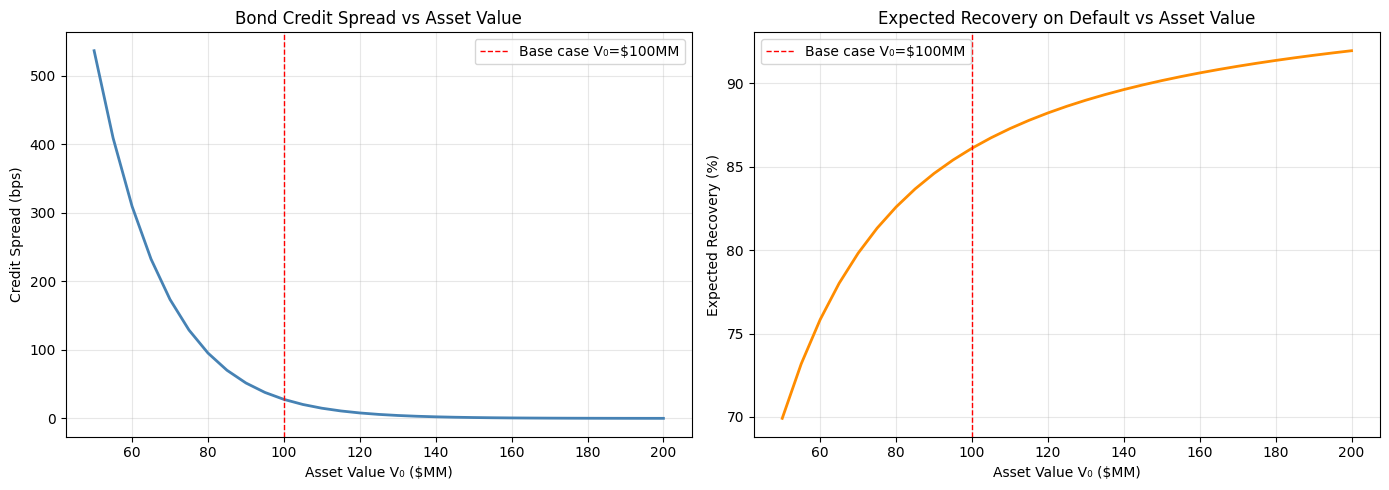

In [8]:
import matplotlib.pyplot as plt

DD        = d2
bond_yield = -np.log(D_fair / F) / T
spread     = bond_yield - r
hazard     = -np.log(1 - PD_rn) / T

print("── Credit Risk Metrics ───────────────────────")
print(f"  Distance to Default      : {DD:.4f}")
print(f"  RN Prob of Default       : {PD_rn:.2%}")
print(f"  Bond Yield               : {bond_yield:.4f} ({bond_yield*100:.2f}%)")
print(f"  Credit Spread            : {spread*1e4:.2f} bps")
print(f"  Flat Hazard Rate         : {hazard*1e4:.2f} bps")
print(f"  Expected Recovery        : {recovery_rate:.2%}")

V_grid = np.arange(50e6, 205e6, 5e6)

spreads    = []
recoveries = []

for V in V_grid:
    d1_ = (np.log(V / F) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2_ = d1_ - sigma * np.sqrt(T)
    E_  = V * norm.cdf(d1_) - PV_F * norm.cdf(d2_)
    D_  = V - E_
    D_  = np.clip(D_, 1e-6, None)
    y_  = -np.log(D_ / F) / T
    s_  = (y_ - r) * 1e4
    pd_ = norm.cdf(-d2_)
    ev_ = V * np.exp(r * T) * norm.cdf(-d1_) / norm.cdf(-d2_) if norm.cdf(-d2_) > 1e-10 else F
    rec_= np.clip(ev_ / F, 0, 1)
    spreads.append(s_)
    recoveries.append(rec_ * 100)

V_mm = V_grid / 1e6

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(V_mm, spreads, color='steelblue', linewidth=2)
axes[0].axvline(100, color='red', linestyle='--', linewidth=1, label='Base case V₀=$100MM')
axes[0].set_title('Bond Credit Spread vs Asset Value')
axes[0].set_xlabel('Asset Value V₀ ($MM)')
axes[0].set_ylabel('Credit Spread (bps)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(V_mm, recoveries, color='darkorange', linewidth=2)
axes[1].axvline(100, color='red', linestyle='--', linewidth=1, label='Base case V₀=$100MM')
axes[1].set_title('Expected Recovery on Default vs Asset Value')
axes[1].set_xlabel('Asset Value V₀ ($MM)')
axes[1].set_ylabel('Expected Recovery (%)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## d. Equity volatility

Compute the Equity Volatility.

What happens to the equity volatility if initial Assets value goes up/down (as of time 0)?

Plot Equity Volatilities of initial Asset values, on a grid from $50 MM to $200 MM in steps of $5 MM.



── Equity Volatility ─────────────────────────
  Asset Volatility σ       : 15.00%
  Equity Volatility σ_E    : 36.04%


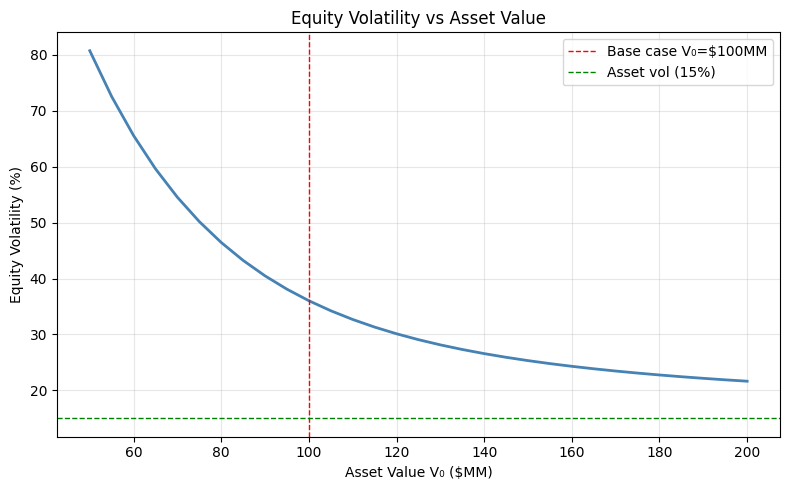

In [9]:
# By Ito's lemma: sigma_E = sigma * V0 * N(d1) / E
sigma_E = sigma * V0 * norm.cdf(d1) / E_fair

print("── Equity Volatility ─────────────────────────")
print(f"  Asset Volatility σ       : {sigma:.2%}")
print(f"  Equity Volatility σ_E    : {sigma_E:.2%}")

sigma_E_grid = []

for V in V_grid:
    d1_ = (np.log(V / F) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2_ = d1_ - sigma * np.sqrt(T)
    E_  = V * norm.cdf(d1_) - PV_F * norm.cdf(d2_)
    sigma_E_ = sigma * V * norm.cdf(d1_) / E_
    sigma_E_grid.append(sigma_E_ * 100)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(V_mm, sigma_E_grid, color='steelblue', linewidth=2)
ax.axvline(100, color='red', linestyle='--', linewidth=1, label='Base case V₀=$100MM')
ax.axhline(sigma * 100, color='green', linestyle='--', linewidth=1, label=f'Asset vol ({sigma:.0%})')
ax.set_title('Equity Volatility vs Asset Value')
ax.set_xlabel('Asset Value V₀ ($MM)')
ax.set_ylabel('Equity Volatility (%)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

-----------------------------------------------------------
# Problem 2: Credit Default Swaps (hazard rate model)

## When computing sensitivities, assume "everything else being equal" (ceteris paribus).

For a better understanding of dependencies, you can use the CDS valuation formulas in the simple hazard rate model (formulas[45] and [46] in Lecture 4).

\begin{align}
PV_{CDS\_PL}\left(c,r,h,R,T\right) = \frac{c}{4 \cdot \left(e^{\left(r+h\right)/4}-1 \right)} \cdot\left[1-e^{-T\cdot\left(r+h\right)}\right] \simeq \frac{c}{r+h} \cdot\left[1-e^{-T\cdot\left(r+h\right)}\right]
\end{align}

\begin{align}
PV_{CDS\_DL}\left(c,r,h,R,T\right) = \frac{\left(1-R\right)\cdot h}{r+h} \cdot\left[1-e^{-T\cdot\left(r+h\right)}\right]
\end{align}

\begin{align}
PV_{CDS} = PV_{CDS\_PL} - PV_{CDS\_DL} \simeq \frac{c - \left(1-R\right)\cdot h}{r+h} \cdot\left[1-e^{-T\cdot\left(r+h\right)}\right]
\end{align}

\begin{align}
CDS\_ParSpread = c \cdot \frac{PV_{CDS\_DL}}{PV_{CDS\_PL}} \simeq \left(1-R\right)\cdot h
\end{align}


## a. True or False (CDS Premium Leg PV)

1. CDS premium leg PV is increasing in CDS Par Spread
2. CDS premium leg PV is increasing in interest rate
2. CDS premium leg PV is increasing in hazard rate
3. CDS premium leg PV is increasing in recovery rate
4. CDS premium leg PV is increasing in coupon
5. CDS premium leg PV is increasing in CDS maturity


**CDS Premium Leg PV** is proportional to the coupon, divided by (r+h), times a maturity factor.

1. **Increasing in CDS Par Spread? TRUE** — Higher par spread implies higher coupon, and the premium leg is linear in the coupon.

2. **Increasing in interest rate? FALSE** — Higher r increases the (r+h) denominator and accelerates discounting, both reducing the premium leg.

3. **Increasing in hazard rate? FALSE** — Higher h increases the (r+h) denominator and raises early termination probability, both reducing the premium leg.

4. **Increasing in recovery rate? FALSE** — Recovery does not appear in the premium leg formula, so no effect.

5. **Increasing in coupon? TRUE** — The premium leg is linear in the coupon, so higher coupon directly increases it.

6. **Increasing in maturity? TRUE** — Higher maturity increases the maturity factor monotonically toward 1, increasing the premium leg.

## b. True or False (CDS Default Leg PV)

1. CDS default leg PV is increasing in CDS Par Spread
2. CDS default leg PV is increasing in interest rate
3. CDS default leg PV is increasing in hazard rate
4. CDS default leg PV is increasing in recovery rate
5. CDS default leg PV is increasing in coupon
6. CDS default leg PV is increasing in CDS maturity

**CDS Default Leg PV** is proportional to (1 - Recovery), times h/(r+h), times a maturity factor.

1. **Increasing in CDS Par Spread? FALSE** — Par spread does not appear in the default leg formula, so no effect.

2. **Increasing in interest rate? FALSE** — Higher r increases the (r+h) denominator and accelerates discounting, both reducing the default leg.

3. **Increasing in hazard rate? TRUE** — Higher h increases the numerator h/(r+h) directly, raising the probability of default and increasing the default leg.

4. **Increasing in recovery rate? FALSE** — Higher recovery reduces the loss given default (1 - Recovery), directly decreasing the default leg.

5. **Increasing in coupon? FALSE** — Coupon does not appear in the default leg formula, so no effect.

6. **Increasing in maturity? TRUE** — Higher maturity increases the maturity factor monotonically toward 1, increasing the default leg.

## c. True or False (CDS PV)


1. CDS PV is increasing in CDS Par Spread
2. CDS PV is increasing in interest rate
3. CDS PV is increasing in hazard rate
4. CDS PV is increasing in recovery rate
5. CDS PV is increasing in coupon
6. CDS PV is increasing in CDS maturity

**CDS PV = Premium Leg - Default Leg**, proportional to [c - (1-R)*h] / (r+h) times a maturity factor. A protection buyer pays the premium leg and receives the default leg.

1. **Increasing in CDS Par Spread? FALSE** — Higher par spread means the contract was struck at a higher coupon than current fair value, increasing the premium leg more than the default leg, reducing CDS PV for the protection buyer.

2. **Increasing in interest rate? FALSE** — Higher r increases (r+h) denominator and accelerates discounting, reducing both legs, but the net PV still decreases.

3. **Increasing in hazard rate? TRUE** — Higher h increases the default leg more than the premium leg, benefiting the protection buyer and increasing CDS PV.

4. **Increasing in recovery rate? FALSE** — Higher recovery reduces the default leg payout (1-R), reducing CDS PV for the protection buyer.

5. **Increasing in coupon? TRUE** — Higher coupon increases the premium leg linearly, directly increasing CDS PV for the protection buyer.

6. **Increasing in maturity? TRUE** — Higher maturity increases both legs, but the net effect is positive for the protection buyer when the contract is in-the-money (h > c/(1-R)).

## d. True or False (CDS Par Spread)


1. CDS Par Spread is increasing in interest rates
2. CDS Par Spread is increasing in hazard rate
3. CDS Par Spread is increasing in recovery rate
4. CDS Par Spread is increasing in coupon
5. CDS Par Spread is increasing in CDS maturity

**CDS Par Spread** is approximately equal to (1 - Recovery) times hazard rate, independent of maturity and interest rates in the simple hazard rate model.

1. **Increasing in interest rates? FALSE** — Interest rates do not appear in the par spread approximation, so no effect.

2. **Increasing in hazard rate? TRUE** — Par spread is directly proportional to the hazard rate; higher default probability increases the par spread.

3. **Increasing in recovery rate? FALSE** — Higher recovery reduces the loss given default (1 - Recovery), directly decreasing the par spread.

4. **Increasing in coupon? FALSE** — Coupon does not appear in the par spread formula; it is determined by hazard rate and recovery only.

5. **Increasing in CDS maturity? FALSE** — Maturity cancels out in the par spread approximation, so no effect.

-----------------------------------------------------------
# Problem 3: Pricing risky bonds in the hazard rate model
## This is building upon
- Homework 2 "Problem 2: US Treasury yield curve calibration (On-The-Runs)",
- Homework 4 "Problem 2: US SOFR swap curve calibration" and
- Homework 4 "Problem 3: CDS Hazard Rate calibration".

## a. Prepare the market data
### Load the symbology + market data dataframes. Calibrate the following curves as of 2026-03-23:
- the "on-the-run" US Treasury curve,
- the US SOFR curve and
- the IBM CDS hazard rate curve (on the top of SOFR discount curve).


In [25]:
import QuantLib as ql
import pandas as pd
import sys

base_path = '/content/unzipped_files/UChicago_FINM_35700_CreditMarkets_Spring2026_Homework_6'
sys.path.append(base_path)
from credit_market_tools import *

calc_date  = ql.Date(23, 3, 2026)
as_of_date = pd.to_datetime('2026-03-23')
ql.Settings.instance().evaluationDate = calc_date

data_path = f'{base_path}/data'

bond_symbology     = pd.read_excel(f'{data_path}/bond_symbology.xlsx')
bond_market_prices = pd.read_excel(f'{data_path}/bond_market_prices_eod.xlsx')
govt_on_the_run    = pd.read_excel(f'{data_path}/govt_on_the_run.xlsx')
sofr_symbology     = pd.read_excel(f'{data_path}/sofr_swaps_symbology.xlsx')
sofr_market_data   = pd.read_excel(f'{data_path}/sofr_swaps_market_data_eod.xlsx')
cds_market_data    = pd.read_excel(f'{data_path}/cds_market_data_eod.xlsx')

bond_market_prices['date'] = pd.to_datetime(bond_market_prices['date'])
sofr_market_data['date']   = pd.to_datetime(sofr_market_data['date'])
cds_market_data['date']    = pd.to_datetime(cds_market_data['date'])

symbology_fixed   = bond_symbology[bond_symbology['cpn_type'] == 'FIXED'].copy()
prices_dt         = bond_market_prices[bond_market_prices['date'] == as_of_date]
treasury_mkt      = symbology_fixed.merge(prices_dt, on='figi', how='inner')
treasury_mkt['midPrice'] = (treasury_mkt['bidPrice'] + treasury_mkt['askPrice']) / 2
govt_combined_otr = treasury_mkt.merge(govt_on_the_run, on=['figi', 'date'], how='inner')
govt_combined_otr = govt_combined_otr.rename(columns={'class_x': 'class', 'ticker_x': 'ticker', 'isin_x': 'isin'})

tsy_yield_curve        = calibrate_yield_curve_from_frame(calc_date, govt_combined_otr, 'midPrice')
tsy_yield_curve_handle = ql.YieldTermStructureHandle(tsy_yield_curve)

sofr_dt       = sofr_market_data[sofr_market_data['date'] == as_of_date].copy()
sofr_combined = sofr_dt.merge(sofr_symbology[['figi', 'tenor']], on='figi', how='left')
sofr_combined = sofr_combined[['tenor', 'midRate']].dropna().reset_index(drop=True)

sofr_helpers = []
for _, row in sofr_combined.iterrows():
    tenor  = int(row['tenor'])
    rate   = float(row['midRate'])
    helper = ql.OISRateHelper(1, ql.Period(tenor, ql.Years),
                              ql.QuoteHandle(ql.SimpleQuote(rate / 100)), ql.Sofr())
    sofr_helpers.append(helper)

sofr_yield_curve        = ql.PiecewiseLinearZero(1, ql.UnitedStates(ql.UnitedStates.GovernmentBond), sofr_helpers, ql.Actual360())
sofr_yield_curve.enableExtrapolation()
sofr_yield_curve_handle = ql.YieldTermStructureHandle(sofr_yield_curve)

CDS_recovery_rate = 0.4
CDS_day_count     = ql.Actual360()
settle_days       = 1
calendar          = ql.TARGET()
CDS_tenors        = [ql.Period(y, ql.Years) for y in [1, 2, 3, 5, 7, 10]]

cds_asof   = cds_market_data[cds_market_data['date'] == as_of_date].copy()
spread_map = {y: cds_asof[f'par_spread_{y}y'].values[0] for y in [1, 2, 3, 5, 7, 10]}

CDS_helpers = []
for tenor in CDS_tenors:
    y      = tenor.length()
    helper = ql.SpreadCdsHelper(
        spread_map[y] / 10000.0, tenor, settle_days, calendar,
        ql.Quarterly, ql.Following, ql.DateGeneration.TwentiethIMM,
        CDS_day_count, CDS_recovery_rate, sofr_yield_curve_handle
    )
    CDS_helpers.append(helper)

hazard_rate_curve         = ql.PiecewiseFlatHazardRate(calc_date, CDS_helpers, CDS_day_count)
hazard_rate_curve.enableExtrapolation()
default_prob_curve_handle = ql.DefaultProbabilityTermStructureHandle(hazard_rate_curve)

print(f"Calc date             : {calc_date}")
print(f"TSY OTR bonds         : {len(govt_combined_otr)}")
print(f"SOFR curve nodes      : {len(sofr_combined)}")
print(f"IBM CDS nodes         : {len(CDS_helpers)}")
print("All curves calibrated successfully.")

Calc date             : March 23rd, 2026
TSY OTR bonds         : 18
SOFR curve nodes      : 8
IBM CDS nodes         : 6
All curves calibrated successfully.


## b. Create the IBM risky bond objects
### Identify the following 5 IBM fixed rate bonds in the symbology table and create the corresponding fixed rate bonds (5 bond objects).

- security = 'IBM 4.3 02/03/31' / figi = 'BBG01ZY076P5'
- security = 'IBM 5 7/8 11/29/32' / figi = 'BBG00001HBL0'
- security = 'IBM 4 3/4 02/06/33' / figi = 'BBG01DMT89M0'
- security = 'IBM 4.95 02/03/36' / figi = 'BBG01ZY07425'
- security = 'IBM 4.7 02/19/46' / figi = 'BBG00C7QBDN2'


Use the create_bond_from_symbology() function (discussed in from Homework 2) to create the bonds objects.

Display the bond cashflows using the get_bond_cashflows() function.

In [26]:
ibm_figis = [
    'BBG01ZY076P5',
    'BBG00001HBL0',
    'BBG01DMT89M0',
    'BBG01ZY07425',
    'BBG00C7QBDN2'
]

ibm_symbology = bond_symbology[bond_symbology['figi'].isin(ibm_figis)].copy()
ibm_symbology = ibm_symbology.rename(columns={'class': 'class'})

print("IBM bonds found:", len(ibm_symbology))
print(ibm_symbology[['security', 'figi', 'coupon', 'maturity']].to_string(index=False))

ibm_bonds = {}
for _, row in ibm_symbology.iterrows():
    bond = create_bond_from_symbology(row)
    ibm_bonds[row['figi']] = bond

print("\nBond objects created:", len(ibm_bonds))

for figi, bond in ibm_bonds.items():
    sec = ibm_symbology.loc[ibm_symbology['figi'] == figi, 'security'].values[0]
    print(f"\n── {sec} ({figi}) ──")
    cf = get_bond_cashflows(bond, calc_date)
    print(cf.to_string(index=False))

IBM bonds found: 5
          security         figi  coupon   maturity
IBM 5 7/8 11/29/32 BBG00001HBL0   5.875 2032-11-29
  IBM 4.7 02/19/46 BBG00C7QBDN2   4.700 2046-02-19
IBM 4 3/4 02/06/33 BBG01DMT89M0   4.750 2033-02-06
  IBM 4.3 02/03/31 BBG01ZY076P5   4.300 2031-02-03
 IBM 4.95 02/03/36 BBG01ZY07425   4.950 2036-02-03

Bond objects created: 5

── IBM 5 7/8 11/29/32 (BBG00001HBL0) ──
       CashFlowDate  CashFlowYearFrac  CashFlowAmount
     May 29th, 2026          0.183333          2.9375
November 29th, 2026          0.683333          2.9375
     May 29th, 2027          1.183333          2.9375
November 29th, 2027          1.683333          2.9375
     May 29th, 2028          2.183333          2.9375
November 29th, 2028          2.683333          2.9375
     May 29th, 2029          3.183333          2.9375
November 29th, 2029          3.683333          2.9375
     May 29th, 2030          4.183333          2.9375
November 29th, 2030          4.683333          2.9375
     May 29th, 

## c. Compute CDS-implied (intrinsic) prices for the IBM fixd rate bonds

Price the 5 IBM bonds using the CDS-calibrated hazard rate curve for IBM (via RiskyBondEngine, discussed in the QuantLib Advanced examples notebook).

Display the clean prices and yields for the 5 test bonds.

You can use the example code below.


In [ ]:
# flat_recovery_rate: use market convention of 40% for "Senior Unsecured" Debt
flat_recovery_rate = 0.40

fixed_rate_bond = ql.FixedRateBond()    # TODO: Pick one of the 3 IBM test bonds !!!

# Risky bond engine uses the calibrated CDS hazard rate curve for pricing credit default risk
risky_bond_engine = ql.RiskyBondEngine(default_prob_curve_handle, flat_recovery_rate, tsy_yield_curve_handle)

fixed_rate_bond.setPricingEngine(risky_bond_engine)

corpBondModelPrice = fixed_rate_bond.cleanPrice()

corpBondModelYield = fixed_rate_bond.bondYield(corpBondModelPrice, ql.Thirty360(ql.Thirty360.USA), ql.Compounded, ql.Semiannual) * 100

print('corpBondCleanPrice', corpBondModelPrice)
print('corpBondYield', corpBondModelYield)


In [28]:
flat_recovery_rate = 0.40

risky_bond_engine = ql.RiskyBondEngine(default_prob_curve_handle, flat_recovery_rate, sofr_yield_curve_handle)

results = []
for figi, bond in ibm_bonds.items():
    sec = ibm_symbology.loc[ibm_symbology['figi'] == figi, 'security'].values[0]
    bond.setPricingEngine(risky_bond_engine)
    clean_price = bond.cleanPrice()
    bond_price  = ql.BondPrice(clean_price, ql.BondPrice.Clean)
    yld = bond.bondYield(bond_price, ql.Thirty360(ql.Thirty360.USA), ql.Compounded, ql.Semiannual) * 100
    results.append({'security': sec, 'figi': figi, 'cleanPrice': round(clean_price, 4), 'yield': round(yld, 4)})

ibm_risky_df = pd.DataFrame(results)
print(ibm_risky_df.to_string(index=False))

          security         figi  cleanPrice  yield
IBM 5 7/8 11/29/32 BBG00001HBL0    108.1935 4.4428
  IBM 4.7 02/19/46 BBG00C7QBDN2     94.9096 5.1101
IBM 4 3/4 02/06/33 BBG01DMT89M0    101.6896 4.4608
  IBM 4.3 02/03/31 BBG01ZY076P5    100.3318 4.2227
 IBM 4.95 02/03/36 BBG01ZY07425    101.7595 4.7239


## d. Compute the "intrinsic" vs market price basis for the IBM bonds

Load the market mid prices and yields from the bond market data dataframe as of 2026-03-23.

Compute and display the basis between the "CDS-implied intrinsic" vs market prices and yields:

- basisPrice = modelPrice - midPrice
- basisYield = modelYield - midYield


Are the CDS intrinsic prices lower or higher than the bond prices observed on the market? What factors could explain the basis?

In [29]:
ibm_market = (bond_market_prices[bond_market_prices['date'] == as_of_date]
              .merge(ibm_symbology[['figi', 'security', 'coupon', 'maturity']], on='figi', how='inner'))

ibm_market['midPrice'] = (ibm_market['bidPrice'] + ibm_market['askPrice']) / 2
ibm_market['midYield'] = (ibm_market['bidYield'] + ibm_market['askYield']) / 2

basis_rows = []
for _, mkt in ibm_market.iterrows():
    figi  = mkt['figi']
    bond  = ibm_bonds[figi]
    model = ibm_risky_df[ibm_risky_df['figi'] == figi].iloc[0]
    basis_rows.append({
        'security'    : mkt['security'],
        'modelPrice'  : round(model['cleanPrice'], 4),
        'midPrice'    : round(mkt['midPrice'], 4),
        'basisPrice'  : round(model['cleanPrice'] - mkt['midPrice'], 4),
        'modelYield'  : round(model['yield'], 4),
        'midYield'    : round(mkt['midYield'], 4),
        'basisYield'  : round(model['yield'] - mkt['midYield'], 4),
    })

basis_df = pd.DataFrame(basis_rows)
print(basis_df.to_string(index=False))

          security  modelPrice  midPrice  basisPrice  modelYield  midYield  basisYield
IBM 5 7/8 11/29/32    108.1935  106.2490      1.9445      4.4428     4.770     -0.3272
  IBM 4.7 02/19/46     94.9096   84.0072     10.9024      5.1101     6.098     -0.9879
IBM 4 3/4 02/06/33    101.6896   99.3591      2.3305      4.4608     4.860     -0.3992
  IBM 4.3 02/03/31    100.3318   98.8036      1.5282      4.2227     4.576     -0.3533
 IBM 4.95 02/03/36    101.7595   97.2583      4.5012      4.7239     5.310     -0.5861


The CDS-implied (intrinsic) prices are **higher** than market prices across all 5 bonds (positive price basis / negative yield basis), meaning the bonds trade **wider** in the cash market than implied by CDS spreads. This is a **negative CDS-bond basis** (cash bonds are cheap relative to CDS). Common explanations:

1. **Liquidity premium** — cash bonds carry an additional liquidity risk premium that widens their spreads beyond what CDS implies, particularly for longer-dated bonds like IBM 4.7 02/19/46 (basis of ~11 points).
2. **Funding & balance sheet costs** — holding cash bonds requires capital and funding; investors demand extra yield compensation that CDS sellers do not.
3. **Real-money forced selling** — bond prices can be depressed by technical factors (fund outflows, index rebalancing) that don't affect CDS markets.
4. **Duration/maturity effect** — the basis is largest for the longest bond (IBM 4.7 02/19/46, ~11 pts), consistent with liquidity and funding costs compounding over longer horizons.

-----------------------------------------------------------
# Problem 4: CDS Intrinisc Index analysis on CDX IG 5Y


## a. Load and explore the CDX IG 5Y symbology, basket composition and market data

Load the `cdx_symbology` Excel file into a dataframe. Identify .

Load the CDX IG 5Y Series 46 indexd the `cdx_basket_composition` Excel file into a dataframe. It contains the CDX IG 5Y Series 46 basket composition and CDS Par Spread quotes as of 2026-03-23.

How many CDS contracts are in the CDX index basket? What are the contractual specs and weights of each CDS? Remember that each CDS is identical to the CDX index and the basket has uniform weights.

Compute mean, median and standard deviation of CDS Par Spreads in the basket.

Sort the basket dataframe by CDS Par Spreads and plot the chart of CDS Par Spreads.

── CDX IG 5Y Series 46 Specs ─────────────────
symbol                         CDX_CDXIG546
ticker                             CDXIG546
class                                Curncy
security                      MARKIT CDX IG
tenor                                    5Y
name              MARKIT CDX.NA.IG.46 06/31
type                    CREDIT DEFAULT SWAP
running_coupon                         0.01
dcc                                 ACT/360
cpn_first               2025-06-20 00:00:00
maturity                2031-06-20 00:00:00
currency                                USD

── Basket Composition ────────────────────────
Number of CDS contracts : 125
Uniform weight          : 80.0000%
  (= 1/125 = 0.8000%)

── Par Spread Statistics (bps) ───────────────
  Mean   : 59.91 bps
  Median : 57.02 bps
  Std Dev: 23.10 bps


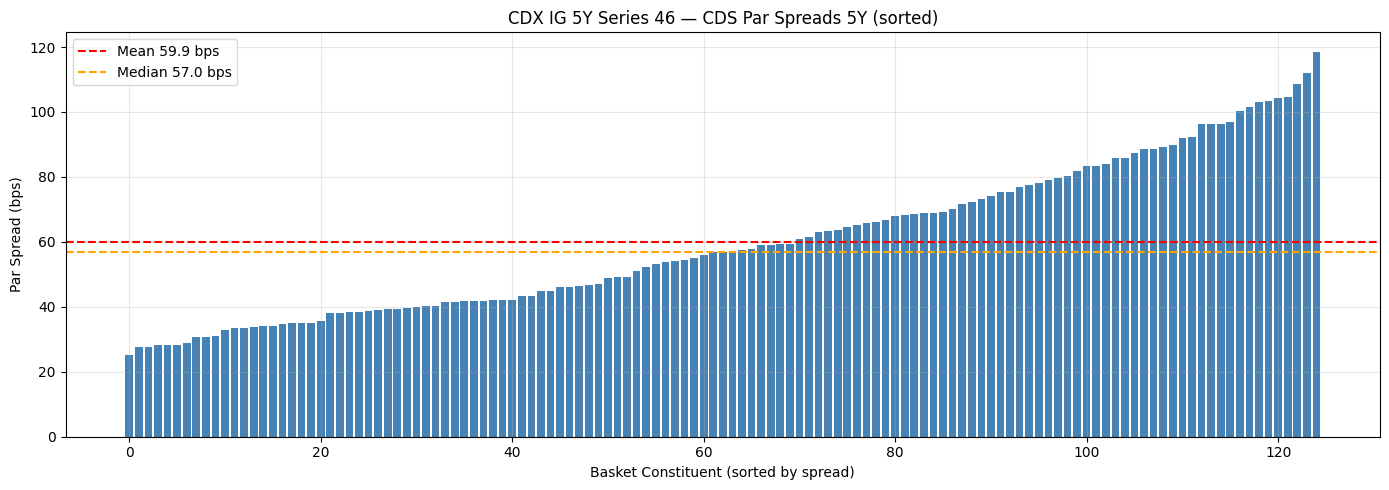

In [34]:
cdx_46_5y_specs = cdx_symbology[cdx_symbology['ticker'] == 'CDXIG546'].iloc[0]

print("── CDX IG 5Y Series 46 Specs ─────────────────")
print(cdx_46_5y_specs.to_string())

print("\n── Basket Composition ────────────────────────")
print(f"Number of CDS contracts : {len(cdx_basket)}")
print(f"Uniform weight          : {cdx_basket['index_weight'].iloc[0]:.4%}")
print(f"  (= 1/125 = {1/125:.4%})")

print("\n── Par Spread Statistics (bps) ───────────────")
spread_col = 'cds_par_spread_5y'
print(f"  Mean   : {cdx_basket[spread_col].mean():.2f} bps")
print(f"  Median : {cdx_basket[spread_col].median():.2f} bps")
print(f"  Std Dev: {cdx_basket[spread_col].std():.2f} bps")

cdx_sorted = cdx_basket.sort_values(spread_col).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(range(len(cdx_sorted)), cdx_sorted[spread_col], color='steelblue', width=0.8)
ax.set_title('CDX IG 5Y Series 46 — CDS Par Spreads 5Y (sorted)')
ax.set_xlabel('Basket Constituent (sorted by spread)')
ax.set_ylabel('Par Spread (bps)')
ax.axhline(cdx_basket[spread_col].mean(),   color='red',    linestyle='--', linewidth=1.5, label=f"Mean {cdx_basket[spread_col].mean():.1f} bps")
ax.axhline(cdx_basket[spread_col].median(), color='orange', linestyle='--', linewidth=1.5, label=f"Median {cdx_basket[spread_col].median():.1f} bps")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## b. Calibrate the US SOFR yield curve (via bootstrapping)
Load the `sofr_swap_symbology` Excel file into a dataframe.

Load the `sofr_swaps_market_data_eod` Excel file into a dataframe.

Follow Homework 4, Problem 2 and calibrate the SOFR discount curve as of 2026-03-23.

In [35]:
print("SOFR curve already calibrated from Problem 3a")
print(f"Reference date  : {sofr_yield_curve.referenceDate()}")
print(f"Curve nodes     : {len(sofr_combined)}")
print(sofr_combined.sort_values('tenor').to_string(index=False))

SOFR curve already calibrated from Problem 3a
Reference date  : March 24th, 2026
Curve nodes     : 8
 tenor  midRate
     1  3.77410
     2  3.68660
     3  3.63160
     5  3.66255
     7  3.75150
    10  3.88475
    20  4.15710
    30  4.10930


## c. Compute the intrinsic Premium Leg PV of the CDX index basket

Follow Homework 4, Problem 3.

For each instrument in the basket, create the CDS object.

Use the calibrated SOFR discount curve and the CDS Par Spreads to calibrate the individual hazard rate / survival probability curves.

Compute the Premium Leg PV for each CDS and aggregate the intrinsic Premium Leg PV of the basket (using basket weights).

Plot the Premium Leg PVs for individual CDS constituents.

── Intrinsic Premium Leg PV ──────────────────
  Weighted basket PV (Premium Leg): 0.046988

── Individual PV stats ───────────────────────
  Mean   : 0.046988
  Median : 0.047043
  Std Dev: 0.000458


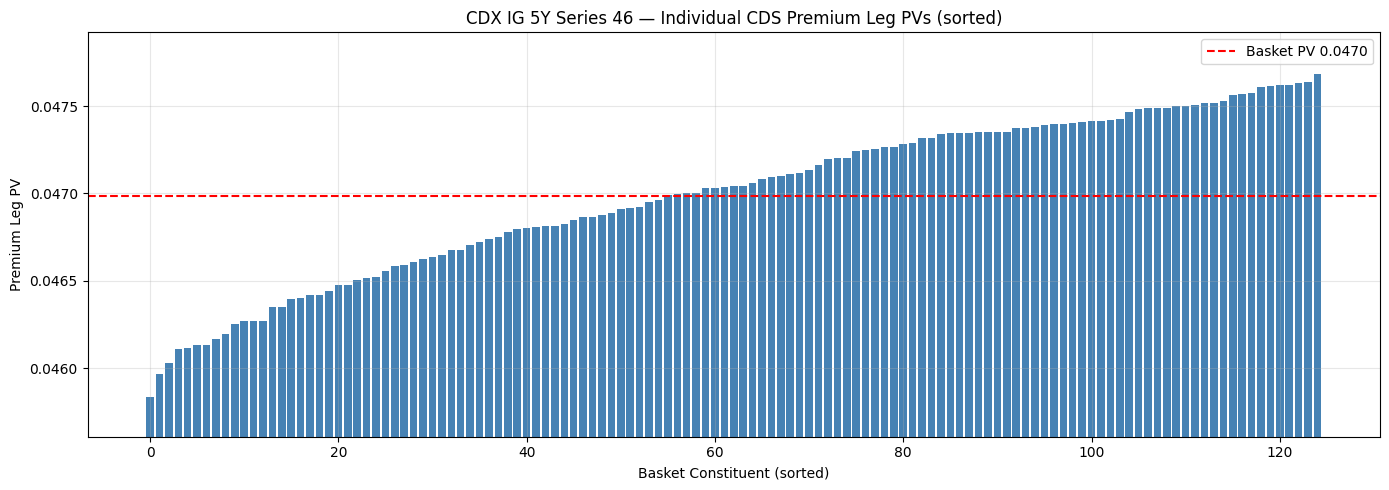

In [38]:
CDS_recovery_rate = 0.40
CDS_day_count     = ql.Actual360()
settle_days       = 1
calendar          = ql.TARGET()
cdx_maturity      = ql.Date(20, 6, 2031)
cdx_coupon        = 0.01

pv_rows = []

for _, row in cdx_basket.iterrows():
    par_spread = row['cds_par_spread_5y'] / 10000.0

    cds_helper = ql.SpreadCdsHelper(
        par_spread, ql.Period(5, ql.Years), settle_days, calendar,
        ql.Quarterly, ql.Following, ql.DateGeneration.TwentiethIMM,
        CDS_day_count, CDS_recovery_rate, sofr_yield_curve_handle
    )

    hz_curve = ql.PiecewiseFlatHazardRate(calc_date, [cds_helper], CDS_day_count)
    hz_curve.enableExtrapolation()
    hz_handle = ql.DefaultProbabilityTermStructureHandle(hz_curve)

    cds = ql.CreditDefaultSwap(
        ql.Protection.Seller, 1.0, cdx_coupon,
        ql.Schedule(calc_date, cdx_maturity, ql.Period(ql.Quarterly),
                    calendar, ql.Following, ql.Unadjusted,
                    ql.DateGeneration.TwentiethIMM, False),
        ql.Following, CDS_day_count
    )

    cds_engine = ql.MidPointCdsEngine(hz_handle, CDS_recovery_rate, sofr_yield_curve_handle)
    cds.setPricingEngine(cds_engine)

    pv_premium_leg = cds.couponLegNPV()

    pv_rows.append({
        'cds_ticker'     : row['cds_ticker'],
        'short_name'     : row['short_name'],
        'cds_par_spread' : row['cds_par_spread_5y'],
        'pv_premium_leg' : pv_premium_leg,
        'weight'         : row['index_weight'] / 100
    })

pv_df = pd.DataFrame(pv_rows)
intrinsic_pv_premium_leg = (pv_df['pv_premium_leg'] * pv_df['weight']).sum()

print(f"── Intrinsic Premium Leg PV ──────────────────")
print(f"  Weighted basket PV (Premium Leg): {intrinsic_pv_premium_leg:.6f}")
print(f"\n── Individual PV stats ───────────────────────")
print(f"  Mean   : {pv_df['pv_premium_leg'].mean():.6f}")
print(f"  Median : {pv_df['pv_premium_leg'].median():.6f}")
print(f"  Std Dev: {pv_df['pv_premium_leg'].std():.6f}")

pv_sorted = pv_df.sort_values('pv_premium_leg').reset_index(drop=True)

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(pv_sorted.index, pv_sorted['pv_premium_leg'], color='steelblue')
ax.axhline(intrinsic_pv_premium_leg, color='red', linestyle='--', linewidth=1.5,
           label=f'Basket PV {intrinsic_pv_premium_leg:.4f}')
ax.set_ylim(pv_sorted['pv_premium_leg'].min() * 0.995,
            pv_sorted['pv_premium_leg'].max() * 1.005)
ax.set_title('CDX IG 5Y Series 46 — Individual CDS Premium Leg PVs (sorted)')
ax.set_xlabel('Basket Constituent (sorted)')
ax.set_ylabel('Premium Leg PV')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## d. Compute the intrinsic Default Leg PV of the CDX index basket

Compute the Default Leg PV for each CDS and determine the intrinsic Default Leg PV of the basket (using basket weights).

Plot the Default Leg PVs for individual CDS constituents.

── Intrinsic Default Leg PV ──────────────────
  Weighted basket PV (Default Leg): -0.028044

── Individual PV stats ───────────────────────
  Mean   : -0.028044
  Median : -0.026823
  Std Dev: 0.010526


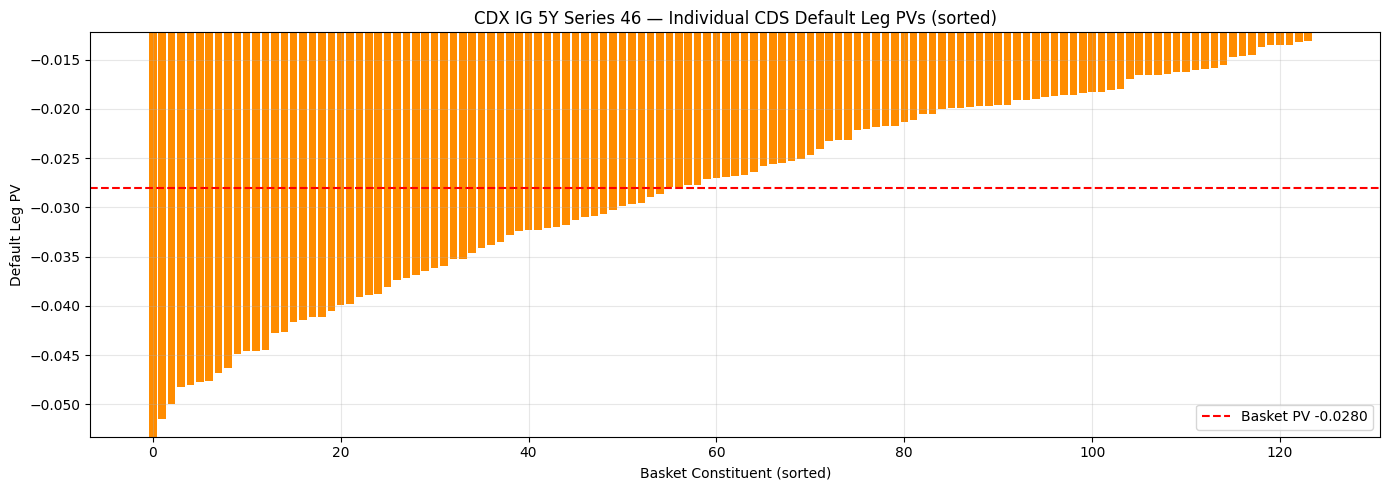

In [39]:
for i, row in cdx_basket.iterrows():
    par_spread = row['cds_par_spread_5y'] / 10000.0

    cds_helper = ql.SpreadCdsHelper(
        par_spread, ql.Period(5, ql.Years), settle_days, calendar,
        ql.Quarterly, ql.Following, ql.DateGeneration.TwentiethIMM,
        CDS_day_count, CDS_recovery_rate, sofr_yield_curve_handle
    )

    hz_curve = ql.PiecewiseFlatHazardRate(calc_date, [cds_helper], CDS_day_count)
    hz_curve.enableExtrapolation()
    hz_handle = ql.DefaultProbabilityTermStructureHandle(hz_curve)

    cds = ql.CreditDefaultSwap(
        ql.Protection.Seller, 1.0, cdx_coupon,
        ql.Schedule(calc_date, cdx_maturity, ql.Period(ql.Quarterly),
                    calendar, ql.Following, ql.Unadjusted,
                    ql.DateGeneration.TwentiethIMM, False),
        ql.Following, CDS_day_count
    )

    cds_engine = ql.MidPointCdsEngine(hz_handle, CDS_recovery_rate, sofr_yield_curve_handle)
    cds.setPricingEngine(cds_engine)

    pv_df.loc[i, 'pv_default_leg'] = cds.defaultLegNPV()

intrinsic_pv_default_leg = (pv_df['pv_default_leg'] * pv_df['weight']).sum()

print(f"── Intrinsic Default Leg PV ──────────────────")
print(f"  Weighted basket PV (Default Leg): {intrinsic_pv_default_leg:.6f}")
print(f"\n── Individual PV stats ───────────────────────")
print(f"  Mean   : {pv_df['pv_default_leg'].mean():.6f}")
print(f"  Median : {pv_df['pv_default_leg'].median():.6f}")
print(f"  Std Dev: {pv_df['pv_default_leg'].std():.6f}")

dl_sorted = pv_df.sort_values('pv_default_leg').reset_index(drop=True)

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(dl_sorted.index, dl_sorted['pv_default_leg'], color='darkorange')
ax.axhline(intrinsic_pv_default_leg, color='red', linestyle='--', linewidth=1.5,
           label=f'Basket PV {intrinsic_pv_default_leg:.4f}')
ax.set_ylim(dl_sorted['pv_default_leg'].min() * 0.98,
            dl_sorted['pv_default_leg'].max() * 1.02)
ax.set_title('CDX IG 5Y Series 46 — Individual CDS Default Leg PVs (sorted)')
ax.set_xlabel('Basket Constituent (sorted)')
ax.set_ylabel('Default Leg PV')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## e. Compute the intrinsic PV and Par Spread of the CDX index basket

Compute the intrinsic index PV.

Compute the CDX instrinsic index Par Spread (using ratio of CDX default vs premium legs).

For comparison, plot the CDS PVs for individual CDS constituents.

── Intrinsic CDX IG 5Y Index ─────────────────
  Premium Leg PV   : 0.046988
  Default Leg PV   : -0.028044
  Intrinsic PV     : 0.018944
  Intrinsic Spread : 59.68 bps


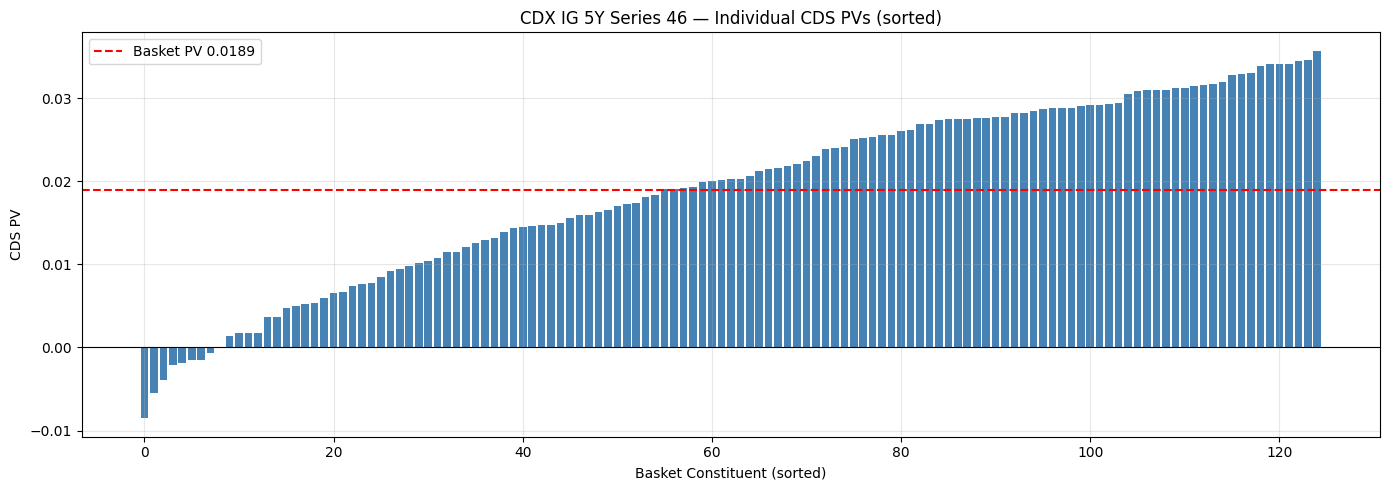

In [40]:
pv_df['pv_cds'] = pv_df['pv_premium_leg'] + pv_df['pv_default_leg']

intrinsic_pv     = (pv_df['pv_cds'] * pv_df['weight']).sum()
intrinsic_spread = (-intrinsic_pv_default_leg / intrinsic_pv_premium_leg) * cdx_coupon * 10000

print(f"── Intrinsic CDX IG 5Y Index ─────────────────")
print(f"  Premium Leg PV   : {intrinsic_pv_premium_leg:.6f}")
print(f"  Default Leg PV   : {intrinsic_pv_default_leg:.6f}")
print(f"  Intrinsic PV     : {intrinsic_pv:.6f}")
print(f"  Intrinsic Spread : {intrinsic_spread:.2f} bps")

cds_sorted = pv_df.sort_values('pv_cds').reset_index(drop=True)

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(cds_sorted.index, cds_sorted['pv_cds'], color='steelblue')
ax.axhline(intrinsic_pv, color='red', linestyle='--', linewidth=1.5,
           label=f'Basket PV {intrinsic_pv:.4f}')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('CDX IG 5Y Series 46 — Individual CDS PVs (sorted)')
ax.set_xlabel('Basket Constituent (sorted)')
ax.set_ylabel('CDS PV')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()